# ChIP and RNA sequencing data plots

## Learning objectives

- Load and explore `SummarizedExperiment` objects for ChIP-seq and RNA-seq data.
- Visualize ChIP-seq signal enrichment across genomic regions using the `EnrichedHeatmap` package.
- Generate and interpret RNA-seq expression heatmaps using the `ComplexHeatmap` package.
- Transform RNA-seq data to highlight differential expression using log fold-change.
- Annotate heatmaps with sample metadata to enhance interpretability.
- Split and visualize RNA-seq data based on gene regulation status (up- or down-regulated).
- Compare and reflect on the similarities and differences in visualization techniques between ChIP-seq and RNA-seq data.

## Loading libraries

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  library(SummarizedExperiment)
  library(GenomicRanges)
  library(EnrichedHeatmap)
  library(ComplexHeatmap)
  library(gUtils)
  library(rtracklayer)
  library(circlize)
}))

## Preparing the ChIP-seq SE object

### Loading the RDS files

As in the first notebook, we load the `SummarizedExperiment` for the ChIP-seq data.

In [2]:
h3k4me3 <- readRDS("data/h3k4me3_se.rds")
h3k4me1 <- readRDS("data/h3k4me1_se.rds")
h3k27me3 <- readRDS("data/h3k27me3_se.rds")
h3k27ac <- readRDS("data/h3k27ac_se.rds")

We check the structure of one of these objects.

In [3]:
h3k4me3

class: RangedSummarizedExperiment 
dim: 4936 4 
metadata(2): final.ext param
assays(2): counts logCPM
rownames: NULL
rowData names(18): annotation geneChr ... PValue qvalue
colnames: NULL
colData names(6): bam.files totals ... group norm.factors

In [4]:
colData(h3k4me3)

DataFrame with 4 rows and 6 columns
               bam.files    totals       ext      rlen       group norm.factors
             <character> <integer> <integer> <integer> <character>    <numeric>
1 ../data/H3K4me3_11ha..  38077388       100        36      11half     0.922457
2 ../data/H3K4me3_11ha..  33020628       100        36      11half     0.852379
3 ../data/H3K4me3_15ha..  78731363       100        49      15half     1.119011
4 ../data/H3K4me3_15ha..  91317562       100        49      15half     1.136546

In [5]:
rd_h3k4me3 <- rowRanges(h3k4me3)
rd_h3k4me3

GRanges object with 4936 ranges and 18 metadata columns:
         seqnames              ranges strand |             annotation   geneChr
            <Rle>           <IRanges>  <Rle> |            <character> <integer>
     [1]     chr1     3667266-3667503      * | Intron (ENSMUST00000..         1
     [2]     chr1     3668238-3668743      * | Intron (ENSMUST00000..         1
     [3]     chr1     3669041-3672787      * |       Promoter (<=1kb)         1
     [4]     chr1     4491514-4493868      * |       Promoter (<=1kb)         1
     [5]     chr1     4496194-4496402      * |       Promoter (<=1kb)         1
     ...      ...                 ...    ... .                    ...       ...
  [4932]     chr2 181765975-181766393      * |       Promoter (<=1kb)         2
  [4933]     chr2 181766549-181770566      * |       Promoter (<=1kb)         2
  [4934]     chr2 181837343-181839141      * |       Promoter (<=1kb)         2
  [4935]     chr2 181863316-181865849      * |       Promoter (

### Exploratory data analysis

Histone methylation (especially active marks like H3K4me3 at promoters) can have very sharp, well-defined boundaries compared to the broader regions of accessibility we see in ATAC-seq or repressive marks.

In [6]:
cat("Summary statistics of H3K4me3 peak width:")
summary(width(rd_h3k4me3))

Summary statistics of H3K4me3 peak width:

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  191.0   279.8   749.0  1283.9  2009.0 18723.0 

We can actually directly compare the peak width distributions and "sharpness" for all the ChIP-seq datasets using histograms.

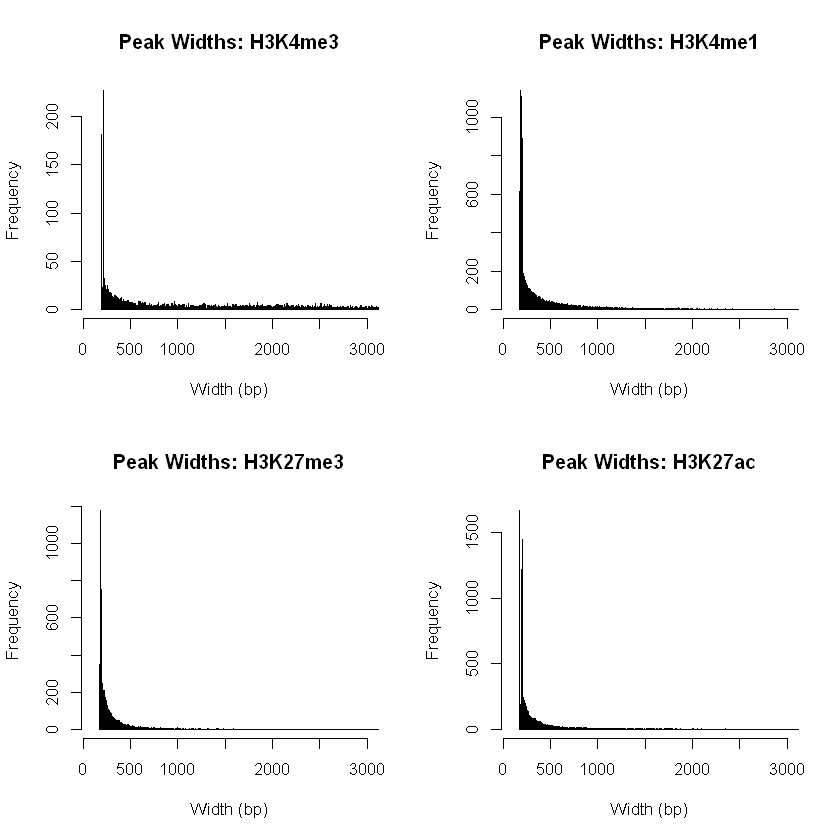

In [7]:
# Create a named list of your 4 SE objects
se_list <- list(
  "H3K4me3" = h3k4me3,
  "H3K4me1" = h3k4me1,
  "H3K27me3" = h3k27me3,
  "H3K27ac" = h3k27ac)

# Set the plotting layout to 2 rows by 2 columns
par(mfrow = c(2, 2))

# Loop through the list
for (mark_name in names(se_list)) {

  # Extract the specific SE object
  se <- se_list[[mark_name]]

  # Extract the genomic ranges
  gr <- rowRanges(se)

  # Plot the histogram
  hist(
    width(gr),
    breaks = 10000,
    xlim = c(100, 3000),    # Zoom in on widths up to 3000bp
    main = paste("Peak Widths:", mark_name),
    xlab = "Width (bp)"
  )
}

# Reset the layout back to a standard 1x1 plot when done
par(mfrow = c(1, 1))

### Interpreting ChIP-seq peak widths

Histone modifications (like H3K4me3 or H3K27ac) are physically attached to the histone proteins that make up a nucleosome. A single nucleosome wraps roughly **147 base pairs** of DNA. Because the modification sits on the nucleosome, the absolute minimum biological "footprint" that can be captured is the size of one nucleosome (around ~150 bp), like we observe on the histograms.

Moreover, during the ChIP-seq protocol, the DNA is physically sheared (via sonication or enzymatic digestion) before sequencing. We typically aim to shear the DNA into fragments of about 200 to 500 base pairs. Because the sequence reads come from the ends of these fragments, it is virtually impossible for the sequencing to resolve a peak that is narrower than the size of the fragments we physically cut the DNA into.

Furthermore, the software used to detect these peaks (usually *MACS2*) has built-in parameters to filter out noise. *MACS2* models the average fragment length (which it often estimates to be ~150-250 bp) and deliberately ignores or merges signal that is smaller than that expected fragment size, because a 30 bp "peak" is almost certainly just random sequencing noise rather than a true modified nucleosome.

While H3K4me3 is typically a sharp mark found at promoters (~200--1000 bp), we observe a subset of peaks extending well beyond 3,000 bp. These **broad H3K4me3 domains** are a well-documented biological phenomenon that typically mark highly transcribed, lineage-defining genes with large CpG islands or multiple transcription start sites.

## Question 1

**Similar to ATAC-seq data, please create `EnrichedHeatmap` for all ChIP-seq datasets and observe difference in genome activity at different genomic regions.**

### Proposed strategy

The goal of this exercise is to visualize and compare the spatial distribution of four different histone modifications (H3K4me3, H3K4me1, H3K27ac, H3K27me3) across specific genomic regions to infer chromatin state and genome activity.

To accurately compare the histone marks, we need a common set of genomic anchor regions. Since ATAC-seq peaks represent all open chromatin (both promoters and enhancers), we can use the **ATAC-seq peak centers** (generated in the [previous notebook](./02-atac_heatmaps.ipynb)) as our universal anchor points. Alternatively, we could combine the peak ranges from all 4 ChIP-seq objects into a consensus set, but using the ATAC peaks is conceptually cleaner as it defines "all potentially active regulatory regions." (And I have the intuition that we would finally combine all of this data at the end of the course ;-)

#### H3K27me3 and the chromatin states

Because ATAC-seq captures open chromatin, using it as our "universal anchor" creates a massive bias. It works beautifully for H3K4me3, H3K4me1, and H3K27ac because those marks actively push the chromatin open. But what about H3K27me3 (the repressive mark)? If a genomic region is heavily repressed by H3K27me3, the chromatin there is tightly closed (inactive). Because it is closed, the ATAC-seq machinery can't get in, meaning there is no ATAC-seq peak there.

If we force H3K27me3 to be plotted using ATAC-seq anchors, we will only see H3K27me3 at weird, transitioning, or "bivalent" regions that happen to be slightly open. We will completely blind ourselves to the deeply repressed, true heterochromatin regions where H3K27me3 is actually the strongest.

#### Expected final figure layout

The final visualization will be a highly informative, multi-panel composite heatmap generated via the `EnrichedHeatmap` and `ComplexHeatmap` packages, as we learned throughout the previous notebook:

- Horizontal panels: 8 side-by-side heatmaps representing the continuous bigWig signal (4 histone marks × 2 developmental stages: E11.5 and E15.5)
- Row splitting (vertical): the rows (genomic regions) will be split by Genomic Annotation (e.g., Promoters vs. Distal Intergenic/Intron, etc.). This allows us to clearly observe how H3K4me3 specifically enriches at promoters, while H3K4me1 enriches at distal enhancers
- Top annotations: above each heatmap, a summarized meta-profile (*line plot*) will show the average signal intensity across the 2kb window, all colored in black (default)
- Ordering: rows will be ordered by the overall intensity of the ATAC-seq signal or the H3K27ac signal to smoothly transition from highly active to less active regions

### Defining anchor regions from differentially accessible chromatin

We will rely on the ATAC-seq data processed in the previous notebook, specifically extracting the `rowRanges` from the ATAC-seq `SummarizedExperiment` and filtering for **significantly differentially accessible regions** (using `qvalue` and `logFC` thresholds) exclusively on chromosomes 1 and 2.

Also remind that once we have isolated these significant ATAC-seq peaks, we used the `resize(width = 1, fix = "center")` function to collapse each peak down to its exact 1-bp midpoint. These midpoints will now serve as the universal anchors for our `EnrichedHeatmap` windows, ensuring that all 4 ChIP-seq datasets are visualized and compared across the exact same spatial coordinates.

In [8]:
# Loading the ATAC-seq dataset
atac <- readRDS("data/atac_se.rds")

# Extracting the Genomic Ranges
rd_atac <- rowRanges(atac)

# Filtering by logFC, qvalue and seqnames (chromosomes)
rd_atac_filtered <- subset(
  rd_atac,
  abs(logFC) >= 0.5 &
  qvalue <= 0.1 &
  seqnames %in% c("chr1", "chr2"))

# Add an "ATAC_" prefix to all the metadata columns in rd_atac_filtered
# (!GOOD PRACTICE preventing multi-omics collisions)
colnames(elementMetadata(rd_atac_filtered)) <- paste(
  "ATAC", colnames(elementMetadata(rd_atac_filtered)), sep = "_"
)

# Finding peak centers
mid_peaks <- resize(rd_atac_filtered, width = 1, fix = "center")

# Identify the ATAC peaks
# (!GOOD PRACTICE for traceability)
names(mid_peaks) <- paste("peak", 1:length(mid_peaks), sep = "_")

In [9]:
sample(mid_peaks, 3)

GRanges object with 3 ranges and 18 metadata columns:
            seqnames    ranges strand |   ATAC_annotation ATAC_geneChr
               <Rle> <IRanges>  <Rle> |       <character>    <integer>
   peak_522     chr1 132542867      * |  Promoter (<=1kb)            1
  peak_1550     chr2 119897244      * |  Promoter (<=1kb)            2
   peak_570     chr1 137323364      * | Distal Intergenic            1
            ATAC_geneStart ATAC_geneEnd ATAC_geneLength ATAC_geneStrand
                 <integer>    <integer>       <integer>       <integer>
   peak_522      132511778    132542890           31113               2
  peak_1550      119897228    119967749           70522               1
   peak_570      136842571    136960448          117878               2
            ATAC_geneId     ATAC_transcriptId ATAC_distanceToTSS
            <character>           <character>          <numeric>
   peak_522       21367  ENSMUST00000186487.6                  0
  peak_1550       29808 ENSMUST00000

### Extracting and normalizing continuous ChIP-seq signal

To extract the continuous ChIP-seq signal, we first retrieve the paths for the 8 ChIP-seq `.bw` (bigWig) files from the `data/` directory. Next, we define our target extraction regions, or `heatmap_windows`, by expanding our ATAC `mid_peaks` to the desired viewing window size (for example, using `resize(mid_peaks, width = 2000, fix = "center")`, just as we did in the previous notebook).

Because there is exactly one bigWig file per condition (4 histone marks × 2 developmental stages), the most elegant and "R-like" approach is to grab all 8 files at once and process them using a single `lapply()` function, rather than writing complicated nested loops. Within this single loop, we use `rtracklayer::import()` and pass our specific windows to the `which` argument. This forces R to dynamically read the continuous signal coverage only within our exact targeted regions directly from the hard drive, massively saving RAM and computation time.

Once the targeted signal is read, the exact same loop immediately feeds it into `normalizeToMatrix()`, outputting a clean list of 8 normalized matrices ready for `EnrichedHeatmap`.

In [10]:
# Get all 8 ChIP-seq bigWig files at once using the regex:
#    ^H3K   -> The file name MUST start with "H3K" (ignores the ATAC files)
#    .*     -> Followed by any sequence of characters (e.g., "4me3_11half")
#    \\.bw$ -> And MUST end exactly with the literal ".bw" extension
chip_bw_files <- list.files("data", pattern = "^H3K.*\\.bw$", full.names = TRUE)

# Give them clean names for the list (e.g., "H3K4me3_11half")
names(chip_bw_files) <- gsub("\\.bw$", "", basename(chip_bw_files))

# Define the actual 2000 bp windows we need for the heatmap
heatmap_windows <- resize(mid_peaks, width = 2000, fix = "center")

# Use a single lapply loop to process all 8 files
chip_matrices <- lapply(chip_bw_files, function(file_path) {

  # Import ONLY the regions overlapping our heatmap_windows
  signal <- rtracklayer::import(file_path, which = heatmap_windows)

  # Convert the signal to a normalized matrix for EnrichedHeatmap
  mat <- normalizeToMatrix(
    signal,                 # bigWig data
    target = mid_peaks,     # anchor ("point 0")
    value_column = "score", # read coverage values
    extend = 1000,          # 2 kb-wide window
    w = 20,                 # binning size of 20 bp
    smooth = TRUE,          # LOESS smoothing
    background = 0          # noise floor
  )

  return(mat)
})

In [11]:
# View of few columns and peaks from the first matrix
chip_matrices[[1]][1:5, 45:50]

,u45,u46,u47,u48,u49,u50
peak_1,0.41785877,0.36655732,0.34175880,0.35650114,0.41155756,0.46620710
peak_2,0.01211658,0.02286782,0.03310115,0.03916861,0.04122399,0.03931726
peak_3,0.11026432,0.07951743,0.05068564,0.03356038,0.02665345,0.02502023
peak_4,0.69515939,0.68179722,0.65382211,0.61544447,0.56406654,0.51900573
peak_5,0.12519382,0.12562346,0.13146672,0.14713624,0.17450900,0.20114145


### Constructing and combining the heatmaps

With our list of 8 normalized matrices prepared, we can now translate this numerical data into a visual map of the chromatin landscape. We will generate an individual `EnrichedHeatmap` object for each matrix. To streamline this process and ensure perfect formatting consistency, we will utilize another upgraded custom function (`make_EH_custom`) that we created in the previous notebook. Rather than building each heatmap from scratch, this function automatically calculates a dynamic color scale based on the 1st and 99th percentiles of each specific matrix (using `circlize::colorRamp2`), adds the top summary meta-profiles, and perfectly aligns the legend ticks.

*Note: This custom function has pre-defined x-axis labels hard-coded as `c("-1kb", "mid", "1kb")`. In the future, if the genomic window being analyzed is different from the current 2000 bp window centered on the ATAC-seq peaks, be sure to make the appropriate changes to the axis_name argument.*

To highlight how these marks behave differently across distinct regulatory elements, we will pass our ATAC peak annotations to the `split_rows` argument (separating, "Promoters" from "Exon", "Intron" and "Intergenic" regions).

Finally, leveraging the power of the `ComplexHeatmap` ecosystem, we can seamlessly concatenate all 8 resulting heatmaps side-by-side using the simple `+` operator. Just as we did before, we will also append a `rowAnnotation` block to the side of the figure—visually tagging the rows with their associated metadata—to create a highly informative, unified composite figure.

In [12]:
# Upgraded version of the original custom function
make_EH_custom <- function(
  norm_mat, hm_name, split_rows = NULL,
  # width = unit(4, "cm"), height = unit(8, "cm"),
  heatmap_cols = c("white", "red"), col_fill = "white",
  line_colors = NULL) {

  # Calculate ticks for the legend
  vmin <- as.numeric(quantile(norm_mat, c(0.01)))
  vmax <- as.numeric(quantile(norm_mat, c(0.99)))
  vmid <- (vmin + vmax) / 2
  legend_ticks <- c(vmin, vmid, vmax)

  # Define color scale based on 1st and 99th percentiles (vmin and vmax)
  col_fun <- colorRamp2(c(vmin, vmax), heatmap_cols)

  # Generate and return the heatmap
  EnrichedHeatmap(
    mat = norm_mat, name = hm_name, row_split = split_rows,
    row_title = NULL, col = col_fun, column_title = hm_name,
    column_title_gp = gpar(fontsize = 10, fill = col_fill),
    # width = width, height = height,
    axis_name = c("-1kb", "mid", "1kb"),
    heatmap_legend_param = list(
      at = legend_ticks, labels = round(legend_ticks, digits = 1),
      title_gp = gpar(fontsize = 8), labels_gp = gpar(fontsize = 7)),
    top_annotation = HeatmapAnnotation(
      lines = anno_enriched(
        # height = unit(2, "cm"),
        # axis_param = list(
        #   side = "right", facing = "inside",
        #   gp = gpar(fontsize = 7, lwd = 0.4)),
        gp = gpar(col = line_colors))))}

Let's now create the indicudal heatmaps objects, using colors similar to what is shown on the course logo.

In [13]:
names(chip_matrices)

[1] "H3K27ac_11half"  "H3K27ac_15half"  "H3K27me3_11half" "H3K27me3_15half"
[5] "H3K4me1_11half"  "H3K4me1_15half"  "H3K4me3_11half"  "H3K4me3_15half"

In [14]:
# Heatmaps for the H3K4me1 data
# REMINDER - `[ ]`returns a list, while `$ ` (or `[[ ]]`) 
# returns the actual object inside the list.
eh_h3k4me1_11h <- make_EH_custom(
  norm_mat = chip_matrices$H3K4me1_11half,
  hm_name = 'K4me1-E11.5',
  col_fill = 'pink',
  # width = NULL, height = NULL,
  # width = unit(1, "null"), height = NULL,
  heatmap_cols = c('white', 'darkblue'))

eh_h3k4me1_15h <- make_EH_custom(
  norm_mat = chip_matrices$H3K4me1_15half,
  hm_name = 'K4me1-E15.5',
  col_fill = 'paleturquoise',
  # width = NULL, height = NULL,
  heatmap_cols = c('white', 'darkblue'))

In [15]:
# Heatmaps for the H3K4me3 data
eh_h3k4me3_11h <- make_EH_custom(
  norm_mat = chip_matrices$H3K4me3_11half,
  hm_name = 'K4me3-E11.5',
  col_fill = 'pink',
  # width = NULL, height = NULL,
  heatmap_cols = c('white', 'darkgreen'))

eh_h3k4me3_15h <- make_EH_custom(
  norm_mat = chip_matrices$H3K4me3_15half,
  hm_name = 'K4me3-E15.5',
  col_fill = 'paleturquoise',
  # width = NULL, height = NULL,
  heatmap_cols = c('white', 'darkgreen'))

In [16]:
# Heatmaps for the H3K27me3 data
eh_h3k27me3_11h <- make_EH_custom(
  norm_mat = chip_matrices$H3K27me3_11half,
  hm_name = 'K27me3-E11.5',
  col_fill = 'pink',
  # width = NULL, height = NULL,
  heatmap_cols = c('white', 'darkorchid'))

eh_h3k27me3_15h <- make_EH_custom(
  norm_mat = chip_matrices$H3K27me3_15half,
  hm_name = 'K27me3-E15.5',
  col_fill = 'paleturquoise',
  # width = NULL, height = NULL,
  heatmap_cols = c('white', 'darkorchid'))

In [17]:
# Heatmaps for the H3K27ac data
eh_h3k27ac_11h <- make_EH_custom(
  norm_mat = chip_matrices$H3K27ac_11half,
  hm_name = 'K27ac-E11.5',
  col_fill = 'pink',
  # width = NULL, height = NULL,
  heatmap_cols = c('white', 'darkred'))

eh_h3k27ac_15h <- make_EH_custom(
  norm_mat = chip_matrices$H3K27ac_15half,
  hm_name = 'K27ac-E15.5',
  col_fill = 'paleturquoise',
  # width = NULL, height = NULL,
  heatmap_cols = c('white', 'darkred'))

_Note: Because we allowed each histone mark to dynamically scale its colors based on its own signal strength (i.e., the color scale is dynamically calculated based on the 1st and 99th percentiles of each individual matrix), we must have separate legends. This means the actual numeric scale is different for every single heatmap. Moreover, `merge_legend` only combines legends that share the exact same title. Therefore, the `merge_legend` argument has no effect here._

In [18]:
# Retrieve the genomic annotations (e.g., "Promoter", "Intron", "Intergenic") 
split_anno <- mid_peaks$ATAC_anno

# Attach the original peak IDs as names to this new vector
names(split_anno) <- names(mid_peaks)

anno_colors <- RColorBrewer::brewer.pal(
  n = length(unique(split_anno)), name = "Set1")

names(anno_colors) <- sort(unique(split_anno))

# Prepare the annotations
eh_annotations <- rowAnnotation(
  df = data.frame(Annotation = split_anno),
  col = list(Annotation = anno_colors),
  show_annotation_name = FALSE
)

In the `ComplexHeatmap` ecosystem, when we combine heatmaps using `+`, they are merged together into a single master object called a HeatmapList. Because the rows are strictly locked together across all 8 heatmaps, we don't need to split them individually.

By passing `split = split_anno` directly into the `draw()` function, we are applying the split globally to the entire composite figure at the very end. We don't have to pass `split_rows` 8 separate times in our `make_EH_custom` function, which guarantees that every single heatmap is forced to split in the exact same way simultaneously. Moreover, R only has to calculate the splitting logic once for the master figure, rather than recalculating it 8 times!

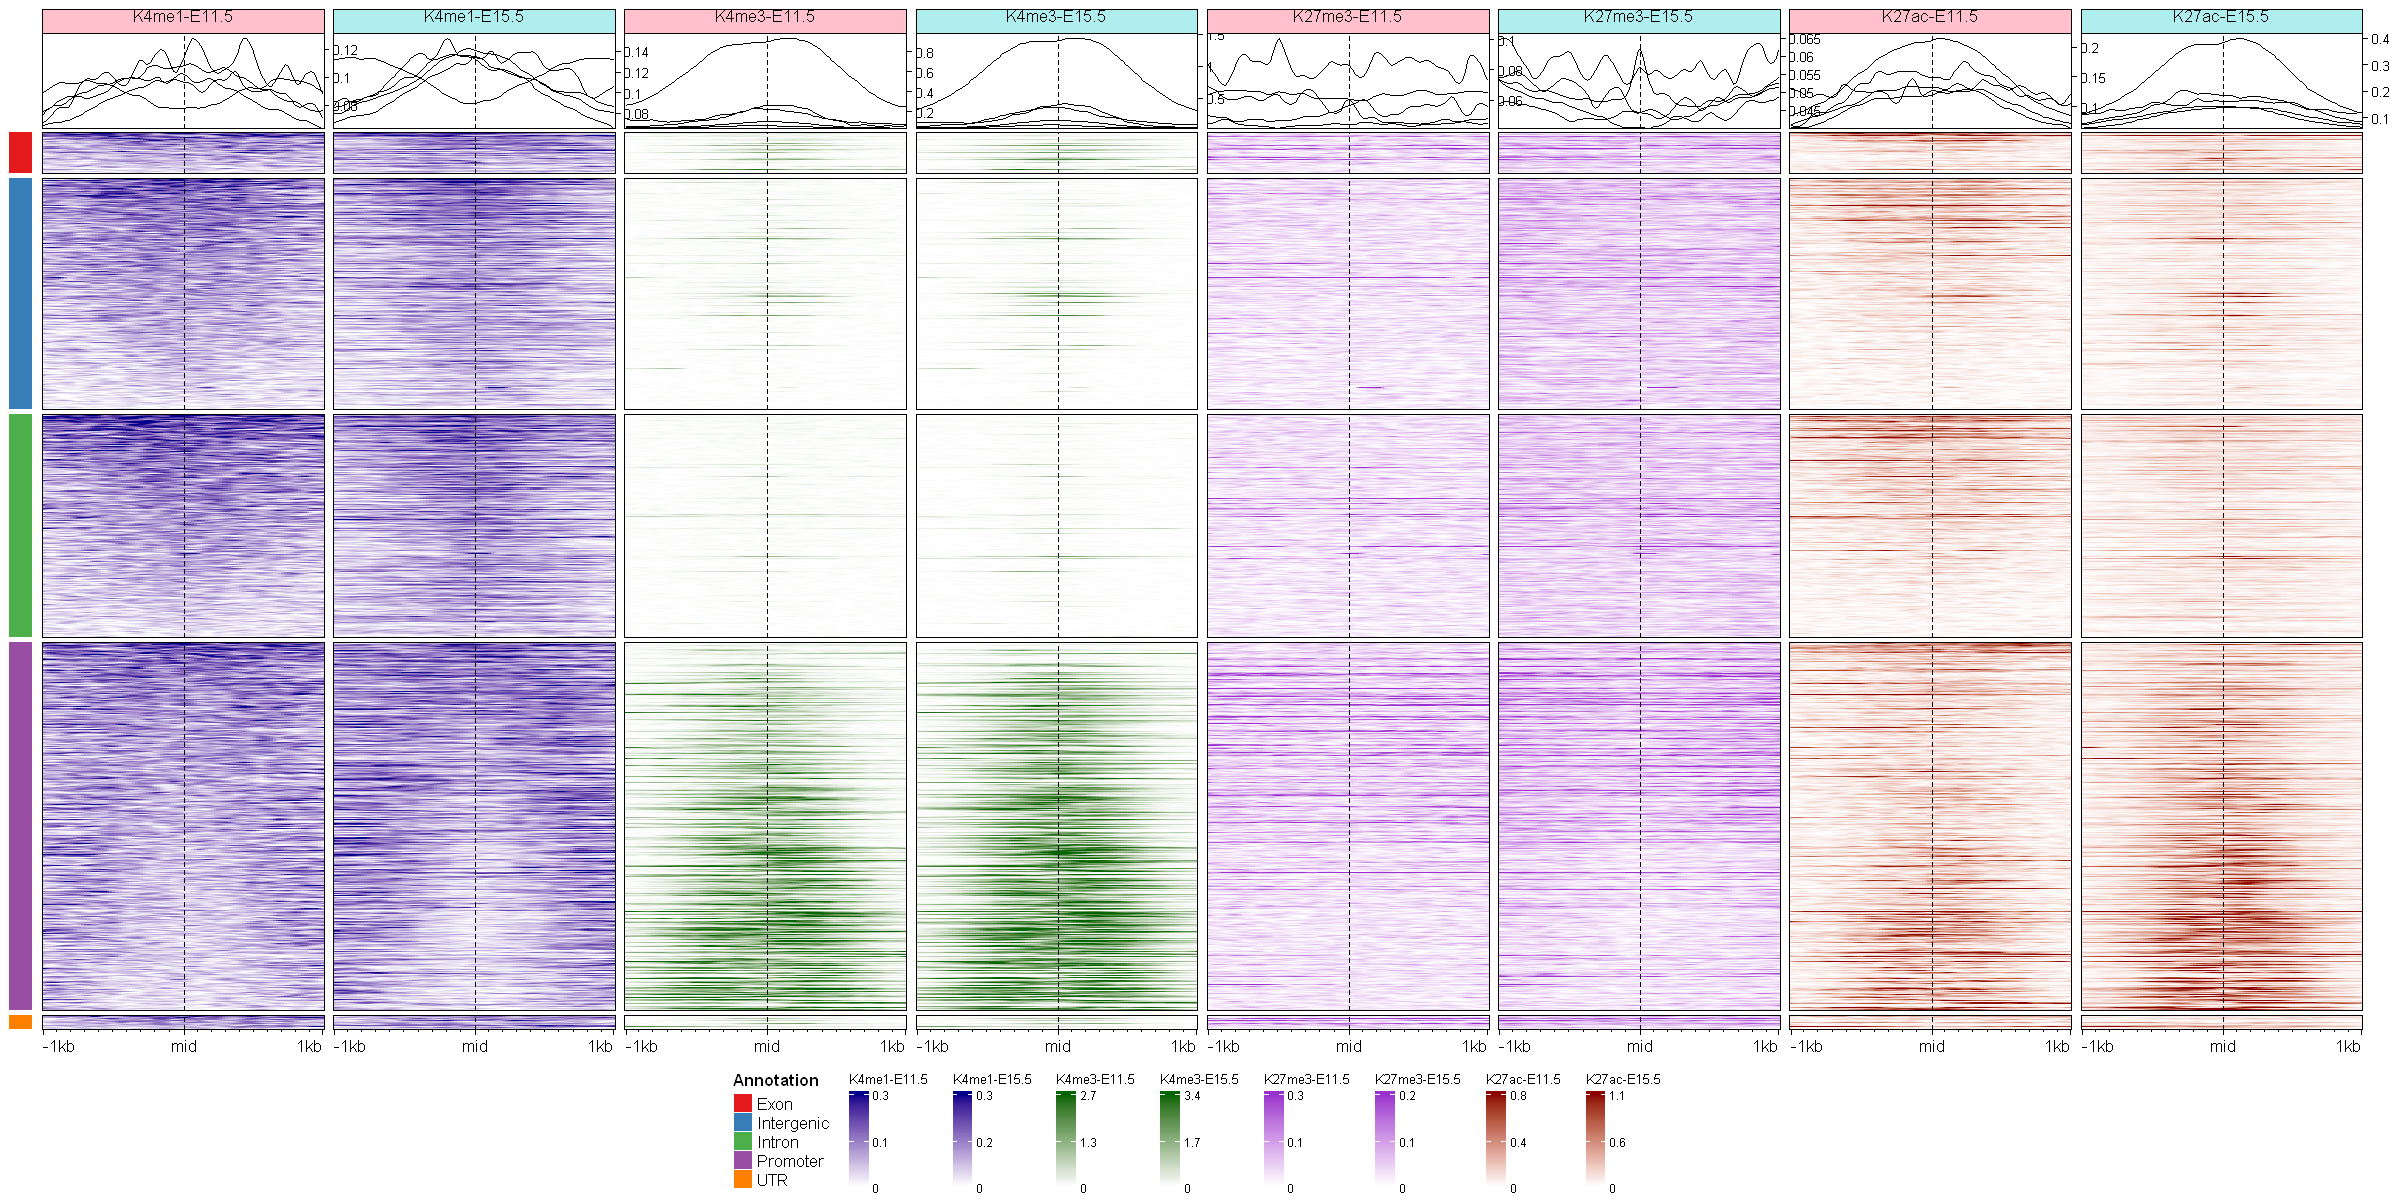

In [19]:
options(repr.plot.width = 20, repr.plot.height = 10)

draw(
  eh_annotations
  + eh_h3k4me1_11h + eh_h3k4me1_15h 
  + eh_h3k4me3_11h + eh_h3k4me3_15h 
  + eh_h3k27me3_11h + eh_h3k27me3_15h 
  + eh_h3k27ac_11h + eh_h3k27ac_15h,
  split = split_anno,
  heatmap_legend_side = "bottom")

### Analyzing histone mark distributions across genomic features

In the composite heatmap, the **H3K4me3** signal is entirely restricted to the violet (*Promoter*) block and absent everywhere else. As the canonical **"Active Promoter"** mark, H3K4me3 is dynamically placed directly around the Transcription Start Site (TSS) by specific enzymes (like MLL/COMPASS complexes) that associate with the transcription machinery. Seeing this signal cleanly restricted to the promoter block confirms the high quality of the data and strictly adheres to expected biological principles.

Unlike H3K4me3, **H3K27ac** marks **both** active promoters and active enhancers, which perfectly explains its strong presence across the promoter, intergenic, and intronic blocks. Interestingly, a temporal shift is visible: H3K27ac signal is higher in distal regions (intergenic/introns) at E11.5, but becomes relatively stronger at promoters by E15.5. This represents a classic developmental signature. At E11.5, cells are still highly plastic and maintain massive networks of active distal enhancers. As they mature to E15.5, many of these broad enhancer networks shut down, while specific terminal genes become aggressively transcribed.

A striking feature of the visualization is the distinct lack of signal (*white space*) directly in the middle of the promoters for **H3K4me1** and, to a lesser extent, **H3K27me3**. Because these heatmaps are centered precisely on *ATAC-seq peaks*, the exact middle (`mid`) represents open chromatin where nucleosomes have been physically displaced to allow transcription factors to bind. Since histone marks require a histone protein to attach to, the signal completely drops to zero in this physical "hole," resulting in a characteristic **bimodal (twin-peak) signal** on the flanking nucleosomes. Furthermore, because H3K4me1 is traditionally an enhancer mark, the central nucleosomes at active promoters get heavily decorated with H3K4me3 instead, physically displacing H3K4me1 to the outer edges and explaining the wide central "dip."

Overall, the visualization successfully captures the known epigenetic landscape: H3K4me3 strictly identifies active promoters, H3K27ac identifies both promoters and enhancers while highlighting developmental transitions, and the fine spatial resolution accurately maps nucleosome depletion directly at the ATAC-seq peak centers.

## Analysis of the RNA-seq data

Having deeply explored the spatial distribution of chromatin accessibility (ATAC-seq; previous notebook) and histone modifications (ChIP-seq) across regulatory elements, we now shift our focus to the functional output of these epigenetic changes: **gene expression**.

Unlike ChIP-seq, where we used `EnrichedHeatmap` to visualize the continuous spatial footprint of modifications across 2kb genomic windows, RNA-seq data is fundamentally different. Here, we are working with discrete transcription levels quantified as **normalized read counts per gene**. Therefore, the heatmaps we generate in this section will be standard expression heatmaps (where rows represent individual genes, columns represent experimental conditions, and color intensity reflects the expression level). This will allow us to identify clusters of co-regulated genes and track how expression profiles shift between E11.5 and E15.5.

### Loading the RNA-seq SE object

To begin, we will load the `SummarizedExperiment` object containing our processed RNA-seq count matrices and associated metadata.

In [20]:
rna <- readRDS("data/rna_se.rds")

rna

class: RangedSummarizedExperiment 
dim: 2216 4 
metadata(0):
assays(2): counts logCPM
rownames(2216): ENSMUSG00000000194 ENSMUSG00000000247 ...
  ENSMUSG00000103948 ENSMUSG00000104257
rowData names(18): Row.names gene_id ... PValue qvalue
colnames(4): RNA_11half_1.tsv.gz RNA_11half_2.tsv.gz
  RNA_15half_1.tsv.gz RNA_15half_2.tsv.gz
colData names(2): sample group

In a typical RNA-seq experiment, finding 1,000 to 4,000 significant Differentially Expressed Genes (DEGs) is a very normal, healthy result👍

### Heatmap of Log-normalized counts

To visualize the global gene expression profile, we will switch from `EnrichedHeatmap` to the [`Heatmap()` function from the `ComplexHeatmap` package](https://jokergoo.github.io/ComplexHeatmap/reference/Heatmap.html) (different from the `heatmap()` function from base R).

Instead of plotting raw read counts, which are heavily skewed by total sequencing depth and extreme outliers, we extract the `logCPM` (*log2 Counts Per Million*) matrix directly from the `SummarizedExperiment` object. The `logCPM` transformation normalizes the data for library size and compresses the massive dynamic range of RNA expression into a scale that is much better suited for visual clustering.

In [21]:
# Back to standard Jupyter Notebook plotting options
options(repr.plot.width = 7, repr.plot.height = 7)

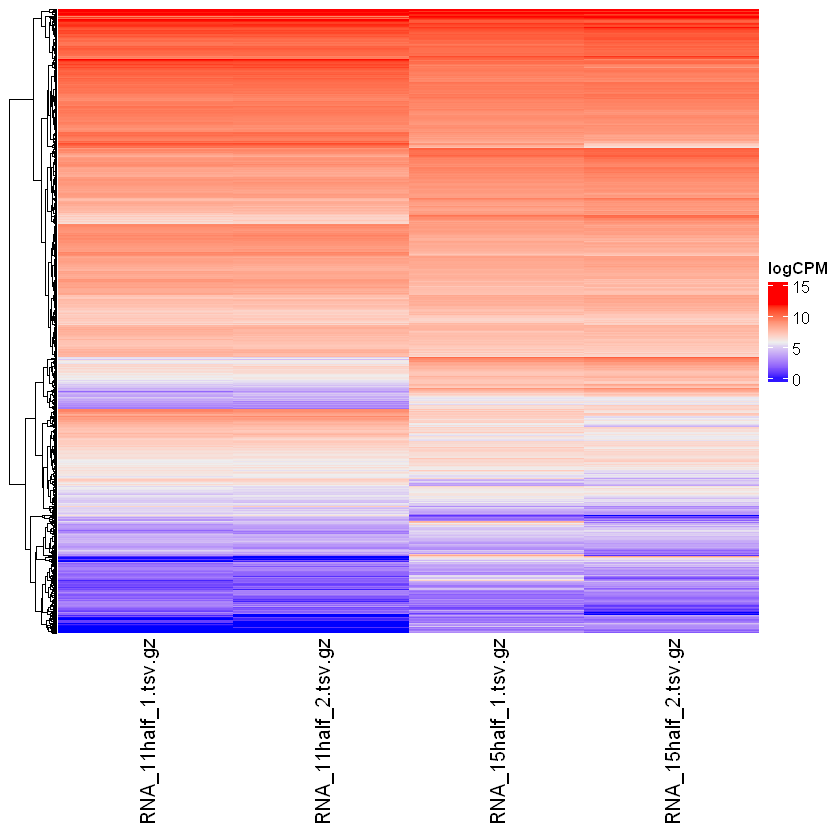

In [22]:
Heatmap(
  matrix = as.matrix(assay(rna, "logCPM")),
  name = "logCPM",  # internal name of the heatmap; also used for the legend title
  cluster_columns = FALSE,  # prevents automatic sample rearrangement
  show_row_names = FALSE
)

### Changing visualization to relative expression

Plotting absolute `logCPM` is useful for seeing overall expression levels, but it can make it difficult to quickly spot dynamic *changes* between the developmental stages. A gene that is constantly highly expressed will visually overwhelm a lowly expressed gene that dramatically doubles in transcription.

To make the developmental shifts immediately obvious, we can transform our absolute expression matrix into a **relative expression matrix**. Because our data is already on a `log2` scale, we can easily *approximate* the log-fold change simply by subtracting the baseline expression (the mean of the E11.5 samples) from every sample in the matrix. 

By centering the data on E11.5, the E11.5 columns will become effectively zero (our baseline). The E15.5 columns will then reflect the relative change: positive values will indicate genes that are **up-regulated** as development proceeds, while negative values will indicate genes that are **down-regulated**.

In [23]:
# Extract the data and immediately cast to a true numeric matrix
log_cpm <- as.matrix(assay(rna, "logCPM"))

# Identify the columns belonging to the E11.5 baseline group
idx_11half <- grep(
  pattern = "11half",
  x = colnames(log_cpm))

# Subtract the E11.5 baseline mean (row-by-row)
counts_fc <- log_cpm - rowMeans(log_cpm[, idx_11half])

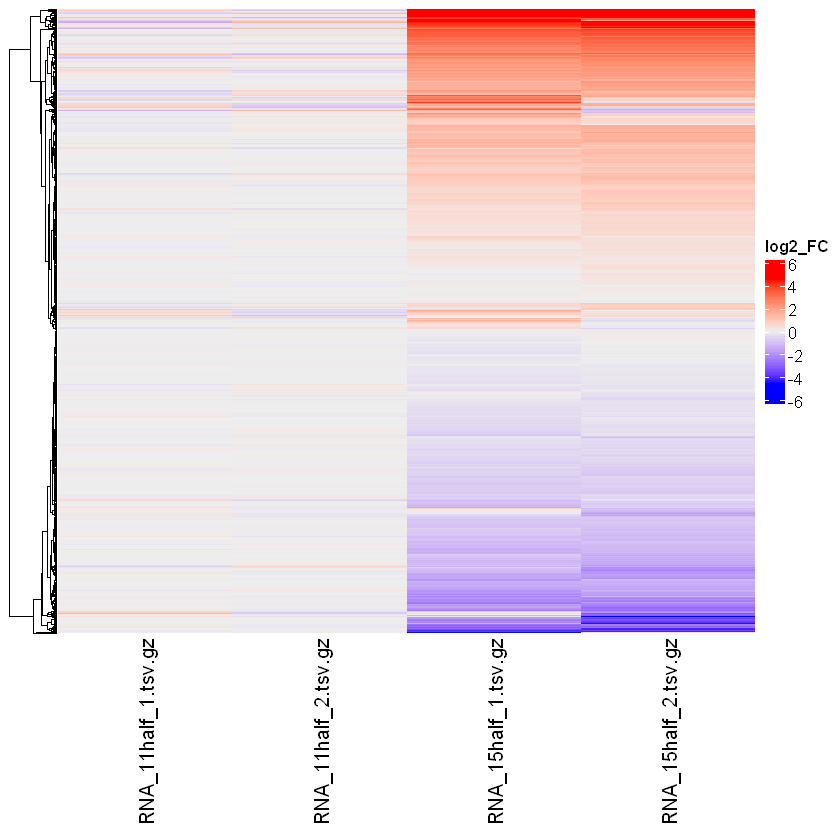

In [24]:
Heatmap(
  matrix = counts_fc,
  name = "log2_FC",  # no parenthesis allowed in the name!
  cluster_columns = FALSE,
  show_row_names = FALSE
)

_Note: while we are manually calculating these relative fold-changes across the matrix columns to generate a centered heatmap here, we will extract and analyze the rigorously calculated statistical `logFC` from the differential analysis table later in the notebook._

### Adding column annotations

Now that our heatmap matrix is structured correctly, we can improve the aesthetics by adding a color-coded annotation bar to the top of our columns. This visually identifies which samples belong to E11.5 and E15.5 at a single glance, without the reader needing to squint at the text labels.

To achieve this, we extract the sample metadata directly from the `rna` object using `colData()`. In addition, we take advantage of the `scales` package: [its `pretty_breaks` function](https://www.rdocumentation.org/packages/scales/versions/0.4.1/topics/pretty_breaks) dynamically looks at the minimum and maximum values of our matrix to calculate exactly 3 "pretty" (round) numbers for our legend ticks. Finally, we adjust the width and height slightly to make the heatmap look more professional.

_Tip: The `drop = FALSE` argument prevents a single-column `data.frame` from collapsing into a nameless vector. This ensures `HeatmapAnnotation` receives a true dataframe (always check the documentation...) and can automatically pull the correct label name (like "Group" or "Stage")._

In [25]:
colData(rna)

DataFrame with 4 rows and 2 columns
                                 sample    group
                            <character> <factor>
RNA_11half_1.tsv.gz RNA_11half_1.tsv.gz   11half
RNA_11half_2.tsv.gz RNA_11half_2.tsv.gz   11half
RNA_15half_1.tsv.gz RNA_15half_1.tsv.gz   15half
RNA_15half_2.tsv.gz RNA_15half_2.tsv.gz   15half

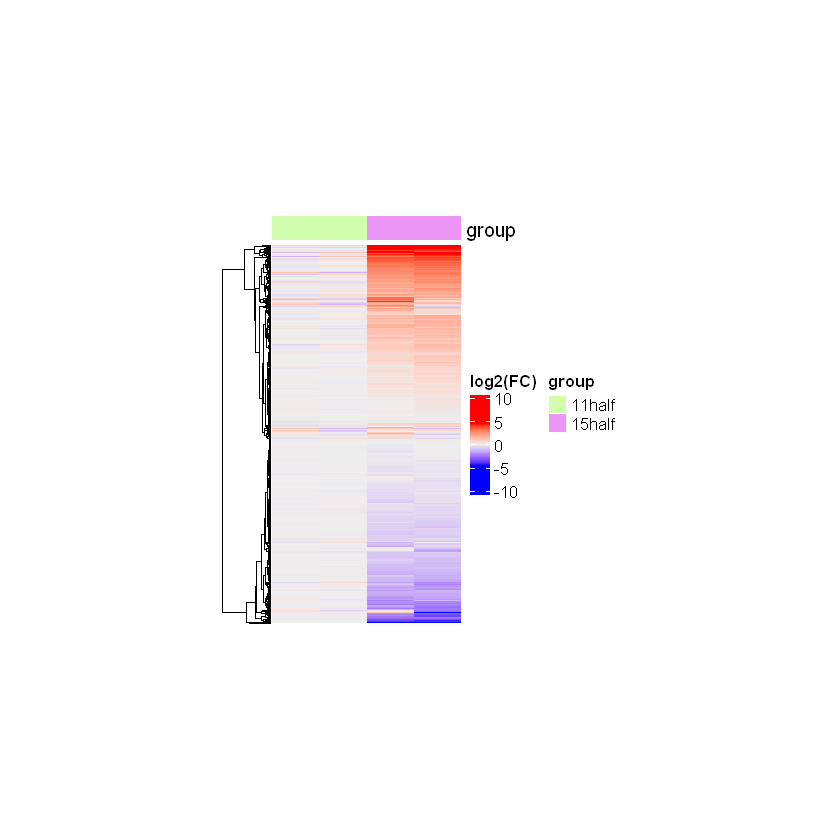

In [26]:
set.seed(100)  # Forces R to always pick the exact same "random" colors

Heatmap(
  matrix = counts_fc,
  # name = "log2_FC",
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = HeatmapAnnotation(
    df = colData(rna)[ , 'group', drop = FALSE]
  ),
  width = unit(4, "cm"),
  height = unit(8, "cm"),
  heatmap_legend_param = list(
    at = scales::pretty_breaks(n = 3)(
      range(counts_fc, na.rm = TRUE)),
    title = "log2(FC)"  # fancier display name
  )
)

## Question 2

**Similar to `EnrichedHeatmap`, we can also split RNA-seq data based on logFC. Can you try to do this?**

Just as we split our spatial ChIP-seq heatmaps by genomic regions (Promoter vs Intergenic), we can split our RNA-seq expression heatmap by gene behavior. The most logical way to do this is to physically separate the genes based on their statistical fold-change (`logFC`).

We will extract the pre-calculated statistical `logFC` from the `rowData(rna)` metadata. Because `logFC` is a continuous number, we must convert it into distinct, discrete groups (e.g., "Up-regulated" and "Down-regulated") so the software knows how to draw the split. We then simply pass this new grouping vector directly into the `row_split` argument of our `Heatmap()` function.

In [27]:
# Extract the statistical logFC for all genes
# Remind rowRanges stores the physical genomic coordinates,
# while rowData stores the statistical metadata as a DataFrame
logFC <- rowData(rna)[, "logFC"]

summary(logFC)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-6.94492 -0.60775  0.05993  0.31056  0.98024  8.98301 

In [28]:
# Categorize the genes (here we split strictly at 0), but we can 
# change the 0 to 1 or 2 if we want to be more strict
gene_status <- ifelse(logFC > 0, "Up-regulated", "Down-regulated")

We can rename the factor levels in the `rna` metadata to the corresponding biological names before we draw the heatmap.

In [29]:
colData(rna)$group <- ifelse(
  colData(rna)$group == "11half", "E11.5", "E15.5")

By default, heatmaps are rendered automatically. To gain precise control over the layout of the various legends, we first save the heatmap to an object and then explicitly render it using the `draw()` function.

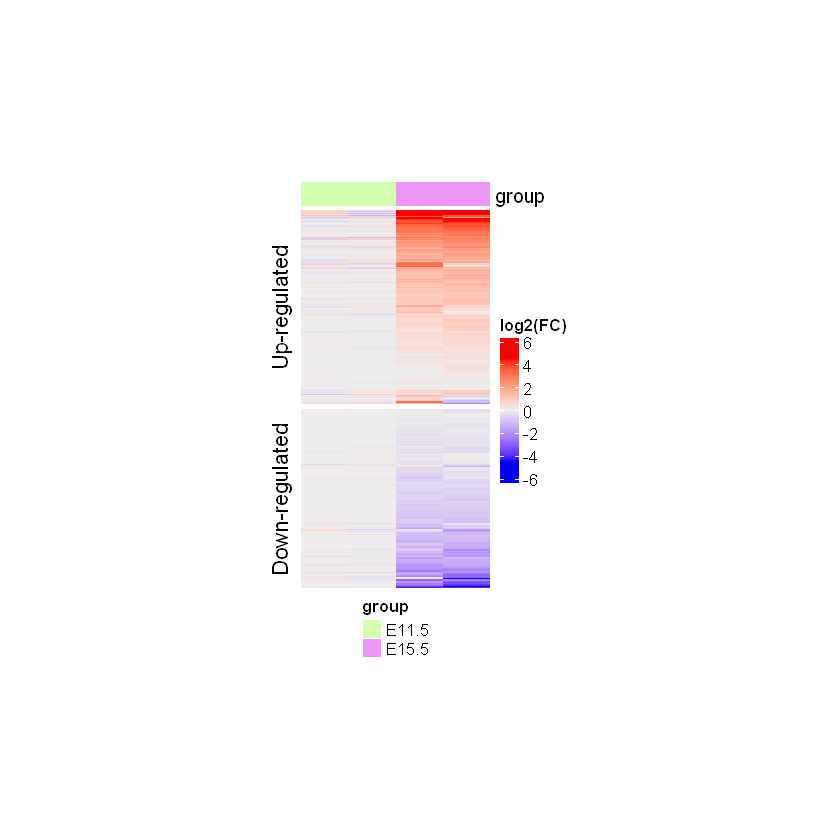

In [30]:
set.seed(100)

ht <- Heatmap(
  matrix = counts_fc,
  row_split = gene_status,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  show_row_dend = FALSE,
  width = unit(4, "cm"), height = unit(8, "cm"),
  top_annotation = HeatmapAnnotation(df = colData(rna)[,2, drop = FALSE]),
  heatmap_legend_param = list(title = "log2(FC)")
)

draw(ht, annotation_legend_side = "bottom", heatmap_legend_side = "right")

### A note on visualizing expression changes

By manually centering the matrix, we preserve all 4 individual columns (samples). This allows us to visually verify replicate consistency, observe the underlying biological noise, and see exactly how each sample behaves within its group. In contrast, the true `logFC` is a single, aggregated statistical value per gene. Plotting it directly would result in a 1-column heatmap that completely hides sample-level variability.

There are many valid ways to visualize RNA-seq data, and we will cover other powerful methods for displaying these statistical results later in the course. For a deeper dive into standard RNA-seq workflows, differential expression statistics, and visualizations, you can refer to my previous [RNA-seq course on GitHub](https://github.com/sbwiecko/RNAseq_UPenn).